<a href="https://colab.research.google.com/github/hongxu-yn/Drought-monitoring-and-assessment/blob/main/src/%E6%B0%94%E8%B1%A1%E5%B9%B2%E6%97%B1%E6%97%B6%E7%A9%BA%E6%A0%BC%E5%B1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the target directory in MyDrive
drive_path = '/content/drive/MyDrive'
repo_url = 'https://github.com/hongxu-yn/Drought-monitoring-and-assessment.git'
repo_name = 'Drought-monitoring-and-assessment' # Extract repo name from URL

# Create the directory if it doesn't exist and change into it
import os
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Change to the Google Drive directory
%cd {drive_path}

# Check if the repository already exists to avoid errors
if not os.path.exists(os.path.join(drive_path, repo_name)):
    print(f"Cloning {repo_url} into {drive_path}")
    !git clone {repo_url}
    print(f"Repository {repo_name} cloned successfully to {drive_path}")
else:
    print(f"Repository {repo_name} already exists in {drive_path}. Skipping clone.")
    print(f"You can update it by navigating to {os.path.join(drive_path, repo_name)} and running `!git pull`")

Mounted at /content/drive
/content/drive/MyDrive
Cloning https://github.com/hongxu-yn/Drought-monitoring-and-assessment.git into /content/drive/MyDrive
Cloning into 'Drought-monitoring-and-assessment'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 25 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 8.30 MiB | 10.74 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Repository Drought-monitoring-and-assessment cloned successfully to /content/drive/MyDrive


In [16]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import xarray as xr
import os
from pathlib import Path
project_dir= Path('/content/drive/MyDrive/Drought-monitoring-and-assessment')
path_station = project_dir/ 'data/站点编号及信息_选定_1969-2025.xlsx'
path_spei = project_dir / 'data/spei/SPEI_month_1969_2025.csv'


df_stations = pd.read_excel(path_station)
spei_df = pd.read_csv(path_spei)
spei_df = spei_df[spei_df['year'].between(2001, 2026)]
combined_df = pd.merge(spei_df, df_stations[['station', 'lat', 'lon']], on='station', how='inner')

# 4. 定义插值网格 (20-30N, 97-107E, Res: 0.05)
res = 0.05
lon_coords = np.arange(97.0, 107.0 + res, res)
lat_coords = np.arange(20.0, 30.0 + res, res)
grid_lon, grid_lat = np.meshgrid(lon_coords, lat_coords)
grid_points = np.column_stack((grid_lon.ravel(), grid_lat.ravel()))


def idw_func(x, y, z, target_pts, p=2):
    known_pts = np.column_stack((x, y))
    dist = cdist(target_pts, known_pts)
    dist = np.where(dist == 0, 1e-10, dist)
    weights = 1.0 / (dist ** p)
    return np.sum(weights * z, axis=1) / np.sum(weights, axis=1)

combined_df['time'] = pd.to_datetime(combined_df[['year', 'month']].assign(day=1))
time_steps = sorted(combined_df['time'].unique())
results = np.zeros((len(time_steps), len(lat_coords), len(lon_coords)))

print(f"开始插值，共 {len(time_steps)} 个月份...")

# 外层循环：支持未来批量处理多个尺度，例如 [1, 3, 6, 12]
for time_scale in range (1,13):
    field_name = f'SPEI{time_scale}_Month'
    output_nc = f'/content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI{time_scale:02d}_month_2001_2025.nc'

    results = np.full((len(time_steps), len(lat_coords), len(lon_coords)), np.nan)

    for i, t in enumerate(time_steps):
        curr_df = combined_df[combined_df['time'] == t].dropna(subset=[field_name, 'lat', 'lon'])

        if not curr_df.empty:
            z_grid = idw_func(curr_df['lon'].values, curr_df['lat'].values,
                              curr_df[field_name].values, grid_points)

            results[i, :, :] = z_grid.reshape(len(lat_coords), len(lon_coords))
        else:
            print(f"警告：{pd.to_datetime(t).strftime('%Y-%m')} 缺失全部站点数据，记为 NaN")

        if (i+1) % 120 == 0:
            print(f"进度 ({field_name}): 已完成 {pd.to_datetime(t).year} 年数据")

    ds = xr.Dataset(
        {"spei": (["time", "lat", "lon"], results)},
        coords={"time": time_steps, "lat": lat_coords, "lon": lon_coords}
    )

    ds.spei.attrs["units"] = "1"
    ds.spei.attrs["long_name"] = f"Standardized Precipitation Evapotranspiration Index ({time_scale}-month)"
    ds.spei.attrs["missing_value"] = np.nan

    ds.to_netcdf(output_nc)
    print(f"[{field_name}] 插值完成！文件已保存至: {output_nc}\n" + "-"*40)

开始插值，共 288 个月份...
进度 (SPEI1_Month): 已完成 2010 年数据
进度 (SPEI1_Month): 已完成 2020 年数据
[SPEI1_Month] 插值完成！文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI01_month_2001_2025.nc
----------------------------------------
进度 (SPEI2_Month): 已完成 2010 年数据
进度 (SPEI2_Month): 已完成 2020 年数据
[SPEI2_Month] 插值完成！文件已保存至: /content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI02_month_2001_2025.nc
----------------------------------------


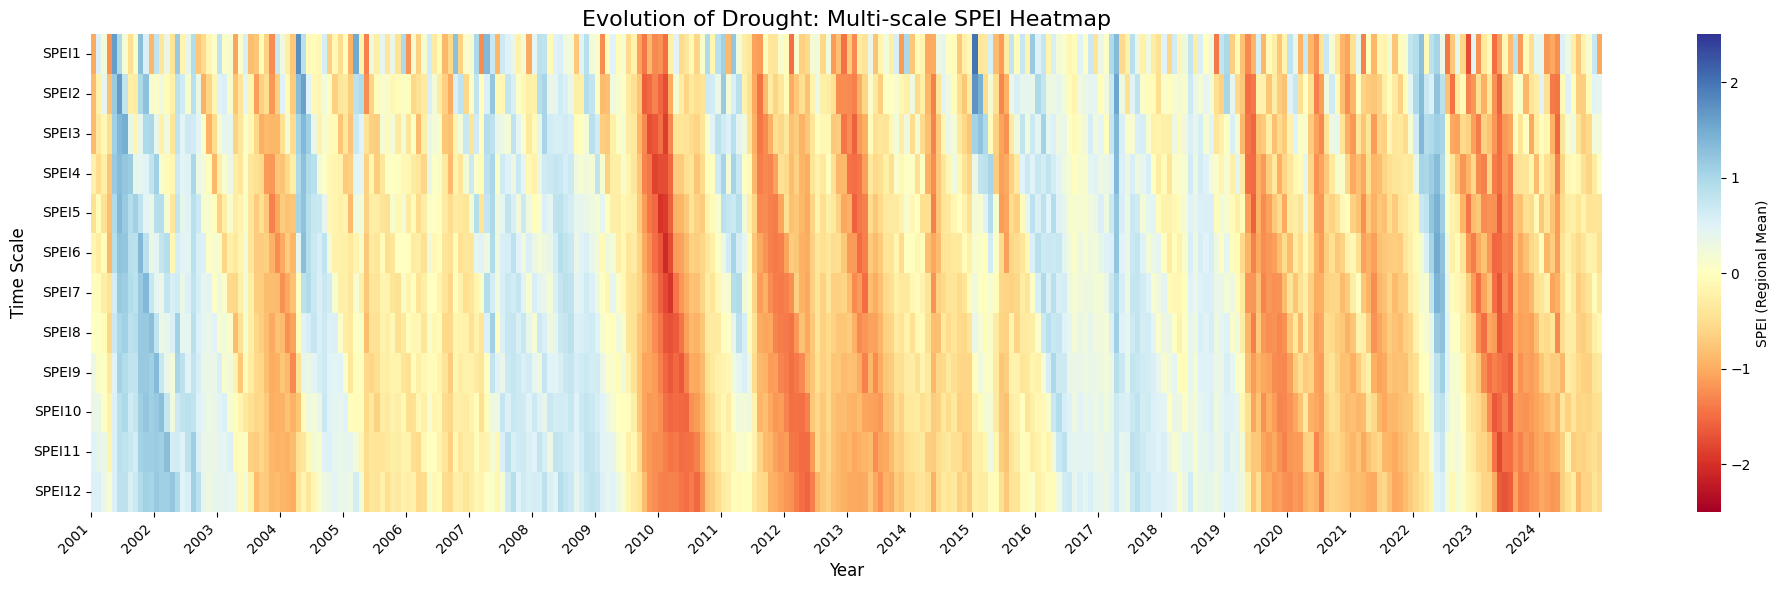

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 假设您的 spei_df 已经读取并过滤好时间 (例如 2001-2025)
# 并且包含了不同时间尺度的列，例如 'SPEI1_Month', 'SPEI3_Month', 'SPEI12_Month' 等

# 1. 自动提取所有 SPEI 列
spei_cols = [col for col in spei_df.columns if 'SPEI' in col.upper()]

# 2. 按照 year 和 month 分组，计算所有站点的平均值
# 这样每个月就只剩下一个代表整个区域的平均 SPEI 值
regional_mean_df = spei_df.groupby(['year', 'month'])[spei_cols].mean().reset_index()

# 3. 创建一个标准的时间列 (Datetime) 用于 X 轴
regional_mean_df['Date'] = pd.to_datetime(regional_mean_df[['year', 'month']].assign(day=1))

# 4. 数据重塑 (Pivot / Transpose)
# 将 Date 设置为索引，只保留 SPEI 列，然后转置 (.T)
# 转置后：行(Index)变成了时间尺度，列(Columns)变成了时间
heatmap_data = regional_mean_df.set_index('Date')[spei_cols].T

# 为了让 Y 轴标签更好看，可以重命名一下索引 (例如去掉 '_Month')
heatmap_data.index = [idx.replace('_Month', '') for idx in heatmap_data.index]

# 5. 开始绘制热力图
# 设置画布大小：因为 2001-2025 有 300 个月，X 轴会比较长，宽度设大一点
plt.figure(figsize=(20, 6))

# 使用 seaborn 绘制热力图
# cmap='RdYlBu': 使用红-黄-蓝的渐变色 (发散型色带)
# center=0: 强制 0 值为中间色，这对于 SPEI 非常重要！
ax = sns.heatmap(
    heatmap_data,
    cmap='RdYlBu',      # 负值为红色(干旱)，正值为蓝色(湿润)
    center=0,           # 0 值为白色/浅黄色(正常)
    vmin=-2.5,          # 设置色标下限
    vmax=2.5,           # 设置色标上限
    cbar_kws={'label': 'SPEI (Regional Mean)'} # 图例标签
)

# 6. 优化 X 轴时间标签显示
# 默认情况下列名是 Timestamp，显示会很拥挤。我们将其格式化为 'YYYY-MM'
dates = heatmap_data.columns
# 每隔 12 个月 (1年) 显示一个刻度
tick_positions = range(0, len(dates), 12)
tick_labels = [dates[i].strftime('%Y') for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

# 设置标题和轴标签
plt.title('Evolution of Drought: Multi-scale SPEI Heatmap', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Time Scale', fontsize=12)

# 调整布局并显示/保存
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei_heatmap.png', dpi=300)
plt.show()

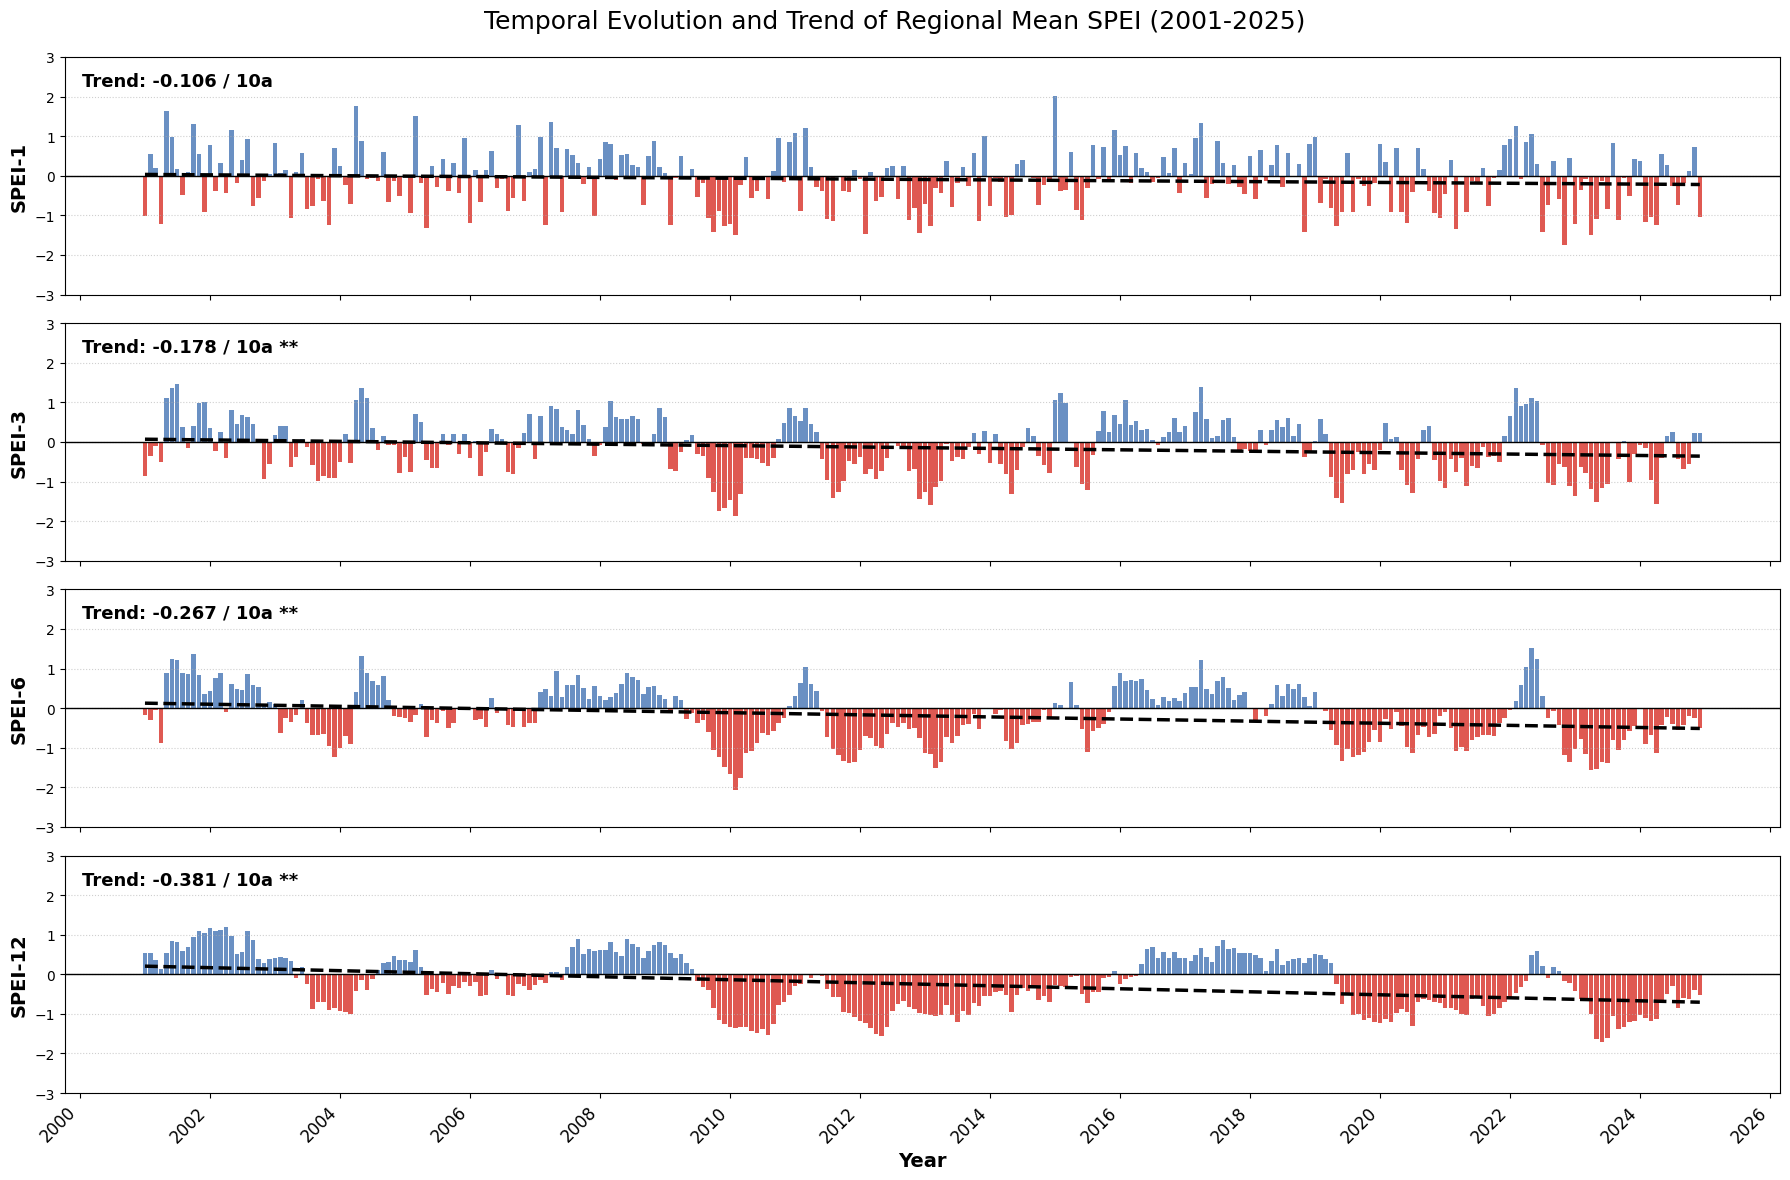

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.stats import linregress

# 定义需要绘制的时间尺度
time_scales = [1, 3, 6, 12]

# 创建一个 4 行 1 列的画布，共享 X 轴
fig, axes = plt.subplots(nrows=len(time_scales), ncols=1, figsize=(18, 12), sharex=True)

for i, scale in enumerate(time_scales):
    ax = axes[i]
    col_name = f'SPEI{scale}_Month'

    if col_name in regional_mean_df.columns:
        # 剔除可能存在的 NaN 值，确保回归计算不出错
        valid_data = regional_mean_df[['Date', col_name]].dropna()
        dates = valid_data['Date']
        values = valid_data[col_name].values

        # 1. 绘制柱状图 (负红正蓝)
        colors = ['#d73027' if val < 0 else '#4575b4' for val in values]
        ax.bar(dates, values, width=25, color=colors, align='center', alpha=0.8)
        ax.axhline(0, color='black', linewidth=1, linestyle='-')

        # 2. 计算线性趋势 (Linear Regression)
        # 构造一个 0, 1, 2... 的整数序列代表逐月时间步长
        x_months = np.arange(len(values))
        slope, intercept, r_value, p_value, std_err = linregress(x_months, values)

        # 计算拟合的 Y 值并绘制虚线趋势线
        trend_line = intercept + slope * x_months
        ax.plot(dates, trend_line, color='black', linestyle='--', linewidth=2.5, zorder=5)

        # 3. 计算年代际变化率与显著性标注
        # slope 是每月的变化率，乘以 120 得到每 10 年的变化率 (/10a)
        # 如果您只想要年际变化率，将其改为 slope * 12，单位写为 /a 即可
        rate_per_decade = slope * 120

        # 根据 p 值确定显著性星号标注
        if p_value < 0.01:
            sig = '**'
        elif p_value < 0.05:
            sig = '*'
        else:
            sig = '' # 不显著

        # 格式化显示的文本信息
        trend_text = f'Trend: {rate_per_decade:.3f} / 10a {sig}'

        # 将文本框放置在子图的左上角
        ax.text(0.01, 0.88, trend_text, transform=ax.transAxes, fontsize=13, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))

        # 设置 Y 轴
        ax.set_ylabel(f'SPEI-{scale}', fontsize=14, fontweight='bold')
        ax.set_ylim(-3, 3)
        ax.grid(True, axis='y', linestyle=':', alpha=0.6)

# 设置 X 轴的格式
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2)) # 每 2 年显示一个刻度，防止过于拥挤
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Year', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)

# 总体标题
plt.suptitle('Temporal Evolution and Trend of Regional Mean SPEI (2001-2025)', fontsize=18, y=0.98)

# 调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.94)

# 保存高分辨率图片，适合期刊发表
# plt.savefig('SPEI_Trend_MultiScale.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
ds

<xarray.Dataset> Size: 93MB
Dimensions:  (time: 288, lat: 201, lon: 201)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2001-01-01 2001-02-01 ... 2024-12-01
  * lat      (lat) float64 2kB 20.0 20.05 20.1 20.15 ... 29.85 29.9 29.95 30.0
  * lon      (lon) float64 2kB 97.0 97.05 97.1 97.15 ... 106.8 106.9 106.9 107.0
Data variables:
    spei     (time, lat, lon) float64 93MB -1.086 -1.086 ... -0.575 -0.5797

In [13]:
curr_df

,Unnamed: 0.1,Unnamed: 0,year,month,SPEI1_Month,SPEI2_Month,SPEI3_Month,SPEI4_Month,SPEI5_Month,SPEI6_Month,SPEI7_Month,SPEI8_Month,SPEI9_Month,SPEI10_Month,SPEI11_Month,SPEI12_Month,station,lat,lon,time
287,659,54,2024,12,-2.099693,-1.294753,0.364965,-0.207061,-0.584693,-0.223239,-0.224991,-0.005304,0.288074,0.051353,0.111129,0.093393,56444,28.4833,98.9167,2024-12-01
575,659,54,2024,12,2.015001,2.268653,1.986085,0.619241,-1.025733,-0.017591,-0.110777,0.410586,0.939924,0.970371,0.860300,0.873897,56483,28.6000,103.9500,2024-12-01
863,659,54,2024,12,-1.160388,-0.605148,-0.284581,1.056803,0.690398,0.667712,0.655566,1.334108,1.486986,1.314951,1.167421,1.092192,56489,28.2333,103.6330,2024-12-01
1151,659,54,2024,12,0.718251,1.368708,1.019499,0.442385,-0.900671,-0.616756,-0.579423,-0.229398,0.009261,-0.094601,-0.207878,-0.211706,56497,28.1000,104.2330,2024-12-01
1439,659,54,2024,12,-1.056932,-1.344008,0.112104,-1.461718,-1.782827,-1.635145,-1.201488,-0.982389,-0.426218,-0.919519,-0.708880,-0.881068,56533,27.7500,98.6667,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31967,659,54,2024,12,0.411538,-0.668664,-0.042054,1.587424,1.059043,0.725487,1.051438,0.989069,0.483694,0.407538,0.241474,0.488640,56992,23.4500,104.7000,2024-12-01
32255,659,54,2024,12,0.390090,-0.671095,-0.567819,0.406172,0.251189,0.240748,0.508839,0.974730,0.438057,0.401956,0.247920,0.471815,56994,23.3833,104.2500,2024-12-01
32543,659,54,2024,12,0.501080,-1.054037,-0.013425,1.301785,1.161504,1.429233,1.239544,1.321125,0.939491,0.903105,0.765311,0.846294,56995,23.0333,104.4170,2024-12-01
32831,659,54,2024,12,0.131539,-1.191349,0.209172,1.624118,1.680771,1.569280,1.874870,2.044521,1.713793,1.589523,1.442824,1.521665,56996,23.1333,104.7000,2024-12-01


In [12]:
time_steps

[Timestamp('2001-01-01 00:00:00'),
 Timestamp('2001-02-01 00:00:00'),
 Timestamp('2001-03-01 00:00:00'),
 Timestamp('2001-04-01 00:00:00'),
 Timestamp('2001-05-01 00:00:00'),
 Timestamp('2001-06-01 00:00:00'),
 Timestamp('2001-07-01 00:00:00'),
 Timestamp('2001-08-01 00:00:00'),
 Timestamp('2001-09-01 00:00:00'),
 Timestamp('2001-10-01 00:00:00'),
 Timestamp('2001-11-01 00:00:00'),
 Timestamp('2001-12-01 00:00:00'),
 Timestamp('2002-01-01 00:00:00'),
 Timestamp('2002-02-01 00:00:00'),
 Timestamp('2002-03-01 00:00:00'),
 Timestamp('2002-04-01 00:00:00'),
 Timestamp('2002-05-01 00:00:00'),
 Timestamp('2002-06-01 00:00:00'),
 Timestamp('2002-07-01 00:00:00'),
 Timestamp('2002-08-01 00:00:00'),
 Timestamp('2002-09-01 00:00:00'),
 Timestamp('2002-10-01 00:00:00'),
 Timestamp('2002-11-01 00:00:00'),
 Timestamp('2002-12-01 00:00:00'),
 Timestamp('2003-01-01 00:00:00'),
 Timestamp('2003-02-01 00:00:00'),
 Timestamp('2003-03-01 00:00:00'),
 Timestamp('2003-04-01 00:00:00'),
 Timestamp('2003-05-

In [11]:
spei_df

,Unnamed: 0.1,Unnamed: 0,year,month,SPEI1_Month,SPEI2_Month,SPEI3_Month,SPEI4_Month,SPEI5_Month,SPEI6_Month,SPEI7_Month,SPEI8_Month,SPEI9_Month,SPEI10_Month,SPEI11_Month,SPEI12_Month,station
31,31,31,2001,1,-0.376338,-0.747831,0.059207,0.286271,0.440154,1.009083,0.776898,1.017988,1.280277,1.738648,1.536258,1.509285,56444
32,32,32,2002,1,0.887180,0.161631,-0.197723,0.409644,-0.431191,-0.627915,-0.521177,-0.524139,-0.374422,-0.294212,-0.370434,-0.454509,56444
33,33,33,2003,1,-0.341086,-0.163191,0.670653,0.383127,0.497483,1.359429,2.046228,1.822412,2.143857,1.853399,1.865275,1.759885,56444
34,34,34,2004,1,1.051257,1.133410,0.128145,0.170065,0.357890,-0.439400,-0.622882,-0.365465,-0.557946,-0.686010,-0.941888,-0.895777,56444
35,35,35,2005,1,-0.031626,-0.136038,-0.651910,0.173068,-0.296395,-1.127608,-0.869755,-0.640133,0.168921,0.127712,0.473552,0.415231,56444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75895,655,50,2020,12,-0.141588,-1.679344,-0.613371,0.011419,-0.306967,-0.713006,-0.696184,-0.782907,-0.598369,-0.422352,-0.473158,-0.530611,59007
75896,656,51,2021,12,1.672609,1.330012,2.088099,1.463900,1.227948,1.144217,0.855730,0.295235,0.233676,0.023020,0.342534,0.291807,59007
75897,657,52,2022,12,0.937283,-0.911125,-0.312200,0.615337,-0.258362,-1.378686,-1.897734,-0.039733,-0.058025,-0.113373,-0.034178,0.151279,59007
75898,658,53,2023,12,-0.666248,-0.273599,-0.670219,-1.184921,0.373658,0.147836,-0.124735,-0.791037,-1.100849,-1.103504,-1.159215,-1.232387,59007


In [6]:
spei_df = spei_df[spei_df['year'].between(2001, 2025)]

# （可选）如果您想确认过滤是否成功，可以打印一下年份的唯一值
print("当前数据包含的年份：", sorted(spei_df['year'].unique()))

当前数据包含的年份： [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [4]:
file_path = '/content/drive/MyDrive/Drought-monitoring-and-assessment/data/spei/SPEI_month_1969_2025.csv'
spei_df = pd.read_csv(file_path)
spei_df

,Unnamed: 0.1,Unnamed: 0,year,month,SPEI1_Month,SPEI2_Month,SPEI3_Month,SPEI4_Month,SPEI5_Month,SPEI6_Month,SPEI7_Month,SPEI8_Month,SPEI9_Month,SPEI10_Month,SPEI11_Month,SPEI12_Month,station
0,0,0,1970,1,0.586047,0.290327,0.217796,-0.391929,-0.600458,-0.774367,-1.015283,-0.770049,-0.889316,-0.889629,-1.090747,-1.173127,56444
1,1,1,1971,1,0.086309,-0.513946,-0.302477,1.168069,0.778865,0.532137,0.577783,0.298646,0.698770,0.930900,1.255219,1.316218,56444
2,2,2,1972,1,0.395749,0.462702,1.229282,0.757013,-0.269353,-0.598058,-0.358511,-0.144341,0.173409,-0.351202,-0.663759,-0.688658,56444
3,3,3,1973,1,0.626074,0.306521,-0.424853,-1.205340,-1.095086,-1.400175,-0.760676,-1.106323,-1.133722,-0.478127,-0.599384,-0.548675,56444
4,4,4,1974,1,0.327151,1.060036,1.473143,0.765227,0.136136,0.404166,0.712926,1.234130,0.954576,1.283286,1.144741,1.325142,56444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75895,655,50,2020,12,-0.141588,-1.679344,-0.613371,0.011419,-0.306967,-0.713006,-0.696184,-0.782907,-0.598369,-0.422352,-0.473158,-0.530611,59007
75896,656,51,2021,12,1.672609,1.330012,2.088099,1.463900,1.227948,1.144217,0.855730,0.295235,0.233676,0.023020,0.342534,0.291807,59007
75897,657,52,2022,12,0.937283,-0.911125,-0.312200,0.615337,-0.258362,-1.378686,-1.897734,-0.039733,-0.058025,-0.113373,-0.034178,0.151279,59007
75898,658,53,2023,12,-0.666248,-0.273599,-0.670219,-1.184921,0.373658,0.147836,-0.124735,-0.791037,-1.100849,-1.103504,-1.159215,-1.232387,59007


In [ ]:
# -*- coding: utf-8 -*-
#arcpy 批量空间插值
import copy
import datetime as datetime0
import datetime
import arcpy
from arcpy.sa import *
import os,sys

arcpy.CheckOutExtension("Spatial")
arcpy.env.overwriteOutput = True

arcpy.env.workspace=r'E:\workspace'
mask_shp=r'E:\gis\boua_s.shp'
arcpy.env.extent =mask_shp

startyear,endyear=1982,2022

#IDW空间插值

power = 2
workpath=r'E:\drought'
time_scale='month'

In [ ]:
#IDW空间插值
print('IDW',datetime0.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
cellSize = 0.01
if cellSize == 0.01: gridpath='1km'
if cellSize ==0.05: gridpath='5km'

for dataname in ['clmSPEI']:
    if dataname=='clmSPEI': datapath='SPEI_TH'
    if dataname=='SPEI':datapath='SPEI_PM'

    spei_shp_path=os.path.join(workpath,'data','SPEI','SPEI',datapath,'month_shp')

    spei_grid_path=os.path.join(workpath,'step01_XY',gridpath)
    if not os.path.exists(spei_grid_path):  os.makedirs(spei_grid_path)
    spei_grid_path=os.path.join(workpath,'step01_XY',gridpath,dataname)
    if not os.path.exists(spei_grid_path):  os.makedirs(spei_grid_path)

    print('CELLSIZE IS：'+str(cellSize)+'输入出数据：'+spei_shp_path+'输出数据：'+spei_grid_path)

    timescales=list(range(11,13))
    for i in timescales:#时间尺度
        sel_d=dataname+str(i)
        fn = os.path.join(spei_shp_path,
                                sel_d+'_Month_'+str(startyear)+'_'+str(endyear)+'.shp')

        outpath=os.path.join(spei_grid_path,sel_d)
        if not os.path.exists(outpath):  os.makedirs(outpath)
        outpath=os.path.join(outpath,'month')
        if not os.path.exists(outpath):  os.makedirs(outpath)

        print('Time Scale'+str(i)+'  '+outpath)
        if not os.path.exists(outpath):  os.makedirs(outpath)
        for iy in range(startyear,endyear+1):
            #print('process year of:'+str(iy))
            for im in range(1,13):
                zField='S'+str(iy*100+im)
                outfn=os.path.join(outpath,
                                   sel_d+'_month_'+str(iy)+'_'+'{:02d}'.format(im)+'.tif')

                outIDW = Idw(fn, zField, cellSize, 2,  RadiusVariable(60, 10))
                outIDW.save(outfn)
                print(outfn+' is done!',datetime0.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('work is done!',datetime0.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


('IDW', '2023-10-01 12:55:06')
CELLSIZE IS：0.01输入出数据：E:\drought\data\SPEI\SPEI\SPEI_TH\month_shp输出数据：E:\drought\step01_XY\1km\clmSPEI
Time Scale11  E:\drought\step01_XY\1km\clmSPEI\clmSPEI11\month
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1982_01.tif is done!', '2023-10-01 12:55:10')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1982_02.tif is done!', '2023-10-01 12:55:12')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1982_03.tif is done!', '2023-10-01 12:55:15')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1982_04.tif is done!', '2023-10-01 12:55:18')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1982_05.tif is done!', '2023-10-01 12:55:20')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1982_06.tif is done!', '2023-10-01 12:55:23')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1982_07.t

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1987_12.tif is done!', '2023-10-01 12:59:05')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1988_01.tif is done!', '2023-10-01 12:59:08')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1988_02.tif is done!', '2023-10-01 12:59:11')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1988_03.tif is done!', '2023-10-01 12:59:14')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1988_04.tif is done!', '2023-10-01 12:59:18')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1988_05.tif is done!', '2023-10-01 12:59:21')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1988_06.tif is done!', '2023-10-01 12:59:25')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1988_07.tif is done!', '2023-10-01 12:59:28')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1993_12.tif is done!', '2023-10-01 13:03:07')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1994_01.tif is done!', '2023-10-01 13:03:10')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1994_02.tif is done!', '2023-10-01 13:03:13')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1994_03.tif is done!', '2023-10-01 13:03:17')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1994_04.tif is done!', '2023-10-01 13:03:33')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1994_05.tif is done!', '2023-10-01 13:03:36')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1994_06.tif is done!', '2023-10-01 13:03:38')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1994_07.tif is done!', '2023-10-01 13:03:41')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1999_11.tif is done!', '2023-10-01 13:07:31')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_1999_12.tif is done!', '2023-10-01 13:07:34')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2000_01.tif is done!', '2023-10-01 13:07:37')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2000_02.tif is done!', '2023-10-01 13:07:41')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2000_03.tif is done!', '2023-10-01 13:07:44')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2000_04.tif is done!', '2023-10-01 13:07:46')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2000_05.tif is done!', '2023-10-01 13:07:49')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2000_06.tif is done!', '2023-10-01 13:07:52')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2005_09.tif is done!', '2023-10-01 13:11:28')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2005_10.tif is done!', '2023-10-01 13:11:32')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2005_11.tif is done!', '2023-10-01 13:11:35')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2005_12.tif is done!', '2023-10-01 13:11:38')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2006_01.tif is done!', '2023-10-01 13:11:42')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2006_02.tif is done!', '2023-10-01 13:11:45')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2006_03.tif is done!', '2023-10-01 13:11:48')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI11\\month\\clmSPEI11_month_2006_04.tif is done!', '2023-10-01 13:11:51')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

...

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1988_06.tif is done!', '2023-10-01 13:29:04')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1988_07.tif is done!', '2023-10-01 13:29:08')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1988_08.tif is done!', '2023-10-01 13:29:11')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1988_09.tif is done!', '2023-10-01 13:29:15')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1988_10.tif is done!', '2023-10-01 13:29:18')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1988_11.tif is done!', '2023-10-01 13:29:21')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1988_12.tif is done!', '2023-10-01 13:29:24')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_1989_01.tif is done!', '2023-10-01 13:29:27')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_03.tif is done!', '2023-10-01 13:38:24')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_04.tif is done!', '2023-10-01 13:38:28')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_05.tif is done!', '2023-10-01 13:38:33')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_06.tif is done!', '2023-10-01 13:38:38')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_07.tif is done!', '2023-10-01 13:38:43')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_08.tif is done!', '2023-10-01 13:38:49')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_09.tif is done!', '2023-10-01 13:38:53')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2000_10.tif is done!', '2023-10-01 13:38:56')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2005_12.tif is done!', '2023-10-01 13:43:18')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2006_01.tif is done!', '2023-10-01 13:43:22')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2006_02.tif is done!', '2023-10-01 13:43:27')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2006_03.tif is done!', '2023-10-01 13:43:31')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2006_04.tif is done!', '2023-10-01 13:43:35')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2006_05.tif is done!', '2023-10-01 13:43:40')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2006_06.tif is done!', '2023-10-01 13:43:45')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2006_07.tif is done!', '2023-10-01 13:43:49')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2011_11.tif is done!', '2023-10-01 13:48:28')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2011_12.tif is done!', '2023-10-01 13:48:33')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2012_01.tif is done!', '2023-10-01 13:48:37')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2012_02.tif is done!', '2023-10-01 13:48:42')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2012_03.tif is done!', '2023-10-01 13:48:47')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2012_04.tif is done!', '2023-10-01 13:48:52')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2012_05.tif is done!', '2023-10-01 13:48:55')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2012_06.tif is done!', '2023-10-01 13:48:58')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2017_11.tif is done!', '2023-10-01 13:53:00')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2017_12.tif is done!', '2023-10-01 13:53:03')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2018_01.tif is done!', '2023-10-01 13:53:06')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2018_02.tif is done!', '2023-10-01 13:53:09')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2018_03.tif is done!', '2023-10-01 13:53:12')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2018_04.tif is done!', '2023-10-01 13:53:15')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2018_05.tif is done!', '2023-10-01 13:53:18')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\clmSPEI12\\month\\clmSPEI12_month_2018_06.tif is done!', '2023-10-01 13:53:21')
('E:\\drought\\step01_XY\\1km\\clmSPEI\\

In [ ]:
print('SPEI站点趋势变化 格点化')
startyear,endyear=1982,2021
season_ID=['S1','S2','S3','S4','GS','Y']
print('IDW',datetime0.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
gridpath,cellSize='8km',  0.083333333
gridpath,cellSize='5km',  0.05
gridpath,cellSize='1km',  0.01

for dataname in ['SPEI','clmSPEI']:
    if dataname=='SPEI':speipath='SPEI_PM'#彭曼公式
    if dataname=='clmSPEI':speipath='SPEI_TH'#

    trend_Shp_Path=os.path.join(workpath,'data','SPEI','SPEI',speipath,'trend_shp')

    Trend_grid_Path=os.path.join(workpath,'step02_trend',gridpath,dataname)
    if not os.path.exists(Trend_grid_Path):  os.makedirs(Trend_grid_Path)

    shpfn=os.path.join(trend_Shp_Path,
                       dataname+'_trend_'+str(startyear)+'_'+str(endyear+1)+'.shp')

    for sel_s in ['S1','S2','S3','S4','GS','Y']:
        for s2 in ['mean','slope','p']:
            zField=sel_s+'_'+s2

            out_rs = Idw(shpfn, zField, cellSize, 2,  RadiusVariable(60, 10))
            s1='_'+sel_s
            if s1=='_Y':s1=''
            outfn='_'.join(['Trend',dataname,'year',str(startyear),str(endyear)+s1,s2])+'.tif'
            if s2=='mean':outfn='_'.join(['Mean',dataname,'year',str(startyear),str(endyear)+s1])+'.tif'
            outfn=os.path.join(Trend_grid_Path,outfn)
            out_rs.save(outfn)
            print(outfn)

print('it is ok',datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

SPEI站点趋势变化 格点化
('IDW', '2023-10-01 17:29:52')
E:\drought\step02_trend\1km\SPEI\Mean_SPEI_year_1982_2021_S1.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S1_slope.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S1_p.tif
E:\drought\step02_trend\1km\SPEI\Mean_SPEI_year_1982_2021_S2.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S2_slope.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S2_p.tif
E:\drought\step02_trend\1km\SPEI\Mean_SPEI_year_1982_2021_S3.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S3_slope.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S3_p.tif
E:\drought\step02_trend\1km\SPEI\Mean_SPEI_year_1982_2021_S4.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S4_slope.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_S4_p.tif
E:\drought\step02_trend\1km\SPEI\Mean_SPEI_year_1982_2021_GS.tif
E:\drought\step02_trend\1km\SPEI\Trend_SPEI_year_1982_2021_GS_slope.t